In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

from sklearn.preprocessing import PolynomialFeatures


from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import BayesianRidge

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix

from sklearn.datasets import make_moons
from sklearn.datasets import make_circles

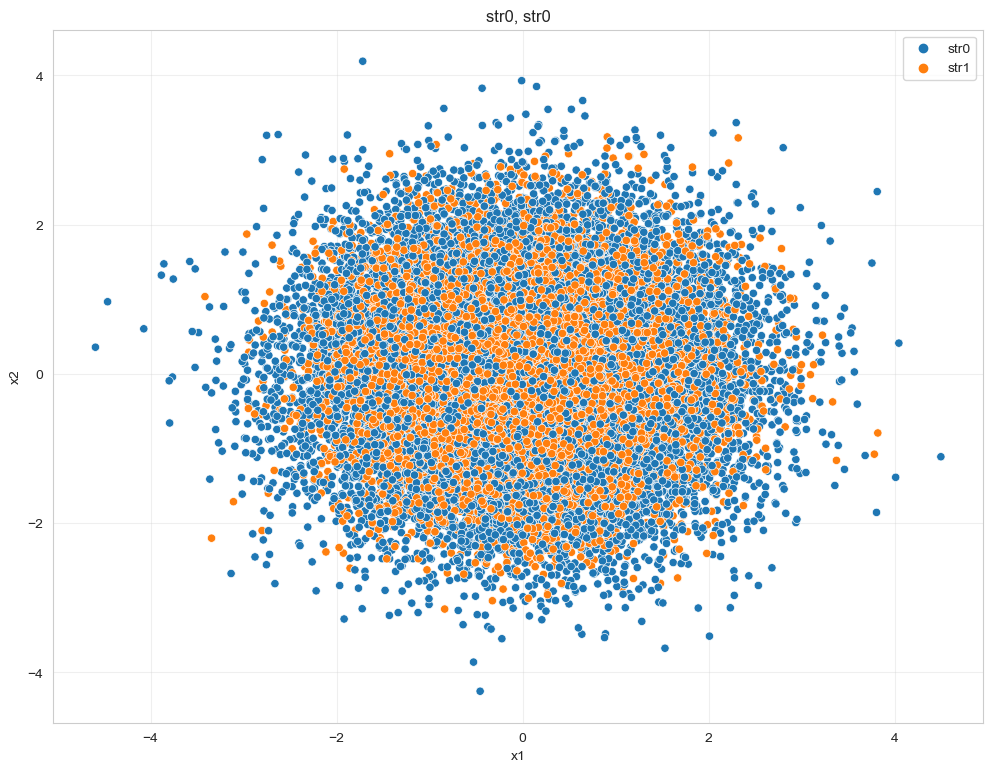

k = 5
k = 30
k = 55
k = 80
k = 105
k = 130
k = 155
k = 180
k = 205
k = 230
k = 255
k = 280


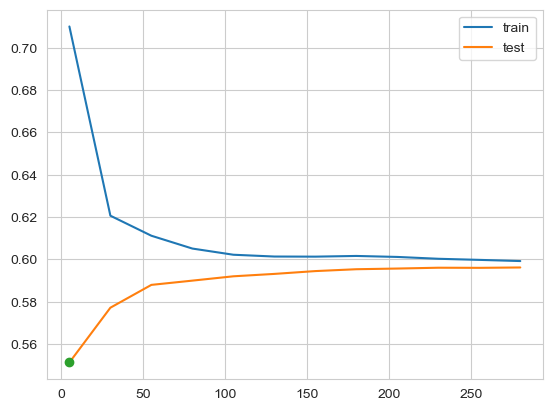

In [4]:
X, y = make_circles(n_samples=30000, noise=0.9, factor=0.1, random_state=42)

df = pd.DataFrame(data = X, columns = ['x1', 'x2'])
df['target'] = y
df['class_name'] = df['target'].map({0: 'str0', 1: 'str1'})

plt.figure(figsize=(12, 9))
sns.scatterplot(data = df, x = 'x1', y = 'x2', hue = 'class_name', alpha=1)
plt.title(df['class_name'].unique()[0] + ', ' + df['class_name'].unique()[0])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

X = df.drop(columns = ['target', 'class_name'])
y = df['target']

horisontal_ax = []

Accuracy_train_list = []
Accuracy_test_list = []

for k in range(5, round(1*len(X)/100), 25):
    

    print('k =', k)
    horisontal_ax.append(k)

    accuracy_train_list = []
    accuracy_test_list = []

    for seed in range(10):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

        model = KNeighborsClassifier(k)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)

        accuracy_train_list.append(accuracy_train)
        accuracy_test_list.append(accuracy_test)

    Accuracy_train_list.append(np.array(accuracy_train_list).mean())
    Accuracy_test_list.append(np.array(accuracy_test_list).mean())

plt.plot(horisontal_ax, Accuracy_train_list, label = 'train')
plt.plot(horisontal_ax, Accuracy_test_list, label = 'test')
plt.plot(horisontal_ax[0], Accuracy_test_list[0], 'o')
plt.legend()
plt.show()

In [5]:
print('Последовательность скоров:')
print(list(np.array(Accuracy_test_list).round(4)))
print('Максимальный скор:', round(np.array(Accuracy_test_list).max(), 4))
print('При n_neighbors =', np.argmax(np.array(Accuracy_test_list))*25 + 5)
print('Прирост скора:', (np.array(Accuracy_test_list).max() - np.array(Accuracy_test_list)[0]).round(4))

Последовательность скоров:
[0.5513, 0.5772, 0.5879, 0.59, 0.592, 0.5931, 0.5945, 0.5953, 0.5957, 0.5961, 0.596, 0.5962]
Максимальный скор: 0.5962
При n_neighbors = 280
Прирост скора: 0.0449


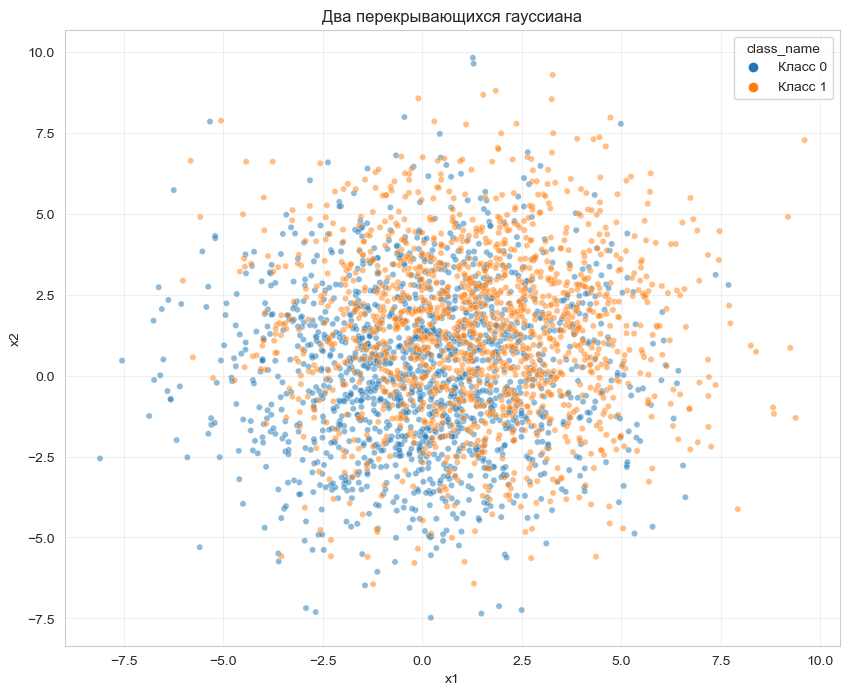

5
30
55
80
105
130
155
180
205
230
255
280
305
330
355
380
405
430
455
480
505
530
555
580
605
630
655
680
705
730
755
780
805
830
855
880


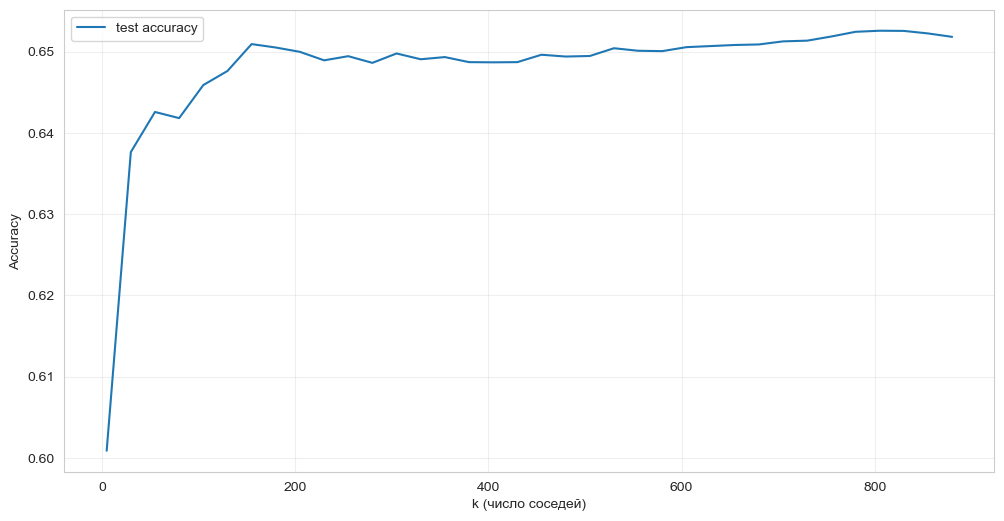

Последовательность скоров:
[0.6009, 0.6376, 0.6426, 0.6418, 0.6459, 0.6476, 0.6509, 0.6505, 0.65, 0.6489, 0.6494, 0.6486, 0.6498, 0.6491, 0.6493, 0.6487, 0.6487, 0.6487, 0.6496, 0.6494, 0.6495, 0.6504, 0.6501, 0.6501, 0.6506, 0.6507, 0.6508, 0.6509, 0.6513, 0.6514, 0.6519, 0.6524, 0.6526, 0.6526, 0.6522, 0.6518]
Максимальный скор: 0.6526
При n_neighbors = 805
Прирост скора: 0.0517


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

np.random.seed(42)

# Два сильно перекрывающихся гауссиана
n_samples = 3000

# Класс 0
X0 = np.random.normal(loc=[0, 0], scale=2.5, size=(n_samples // 2, 2))
y0 = np.zeros(n_samples // 2)

# Класс 1: среднее смещено, но перекрытие огромное из-за большой дисперсии
X1 = np.random.normal(loc=[1.5, 1.5], scale=2.5, size=(n_samples // 2, 2))
y1 = np.ones(n_samples // 2)

X = np.vstack([X0, X1])
y = np.concatenate([y0, y1])

df = pd.DataFrame(data=X, columns=['x1', 'x2'])
df['target'] = y
df['class_name'] = df['target'].map({0: 'Класс 0', 1: 'Класс 1'})

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='x1', y='x2', hue='class_name', alpha=0.5, s=20)
plt.title('Два перекрывающихся гауссиана')
plt.grid(True, alpha=0.3)
plt.show()

horisontal_ax = []
Accuracy_test_list = []

# k от 1 до 30% данных с шагом 5
max_k = int(0.3 * n_samples)
for k in range(5, max_k, 25):
    print(k)
    horisontal_ax.append(k)
    accuracy_test_list_curr = []

    for seed in range(50):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)
        model = KNeighborsClassifier(k)
        model.fit(X_train, y_train)
        accuracy_test_list_curr.append(accuracy_score(y_test, model.predict(X_test)))

    Accuracy_test_list.append(np.mean(accuracy_test_list_curr))

plt.figure(figsize=(12, 6))
plt.plot(horisontal_ax, Accuracy_test_list, label='test accuracy')
plt.xlabel('k (число соседей)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print('Последовательность скоров:')
print(list(np.array(Accuracy_test_list).round(4)))
print(f'Максимальный скор: {np.max(Accuracy_test_list):.4f}')
print(f'При n_neighbors = {horisontal_ax[np.argmax(Accuracy_test_list)]}')
print(f'Прирост скора: {(np.max(Accuracy_test_list) - Accuracy_test_list[0]):.4f}')


In [7]:
0.3*3000

900.0

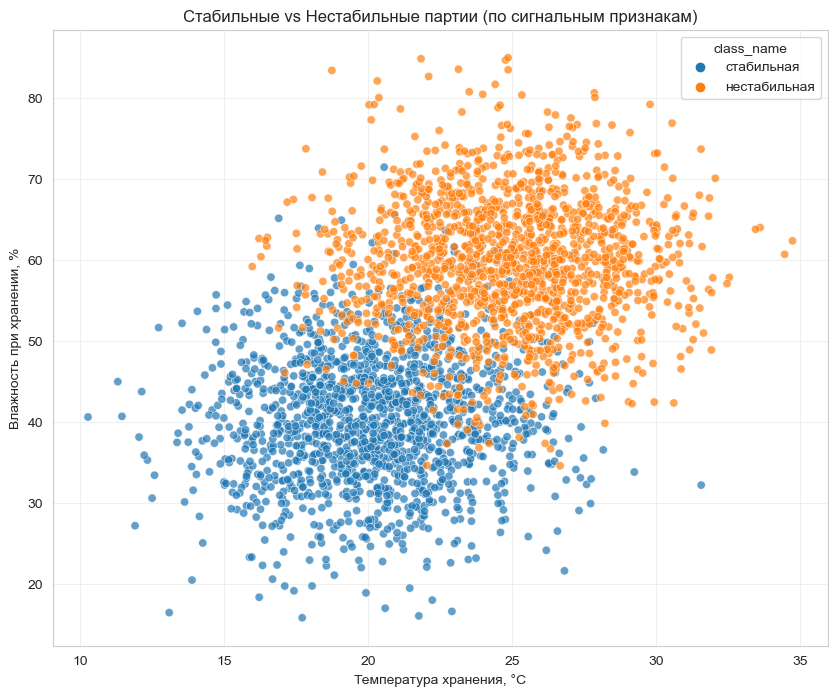

5
15
25
35
45
55
65
75
85
95
105
115
125
135
145
155
165
175
185
195
205
215
225
235
245
255
265
275
285
295
305
315
325
335
345
355
365
375
385
395


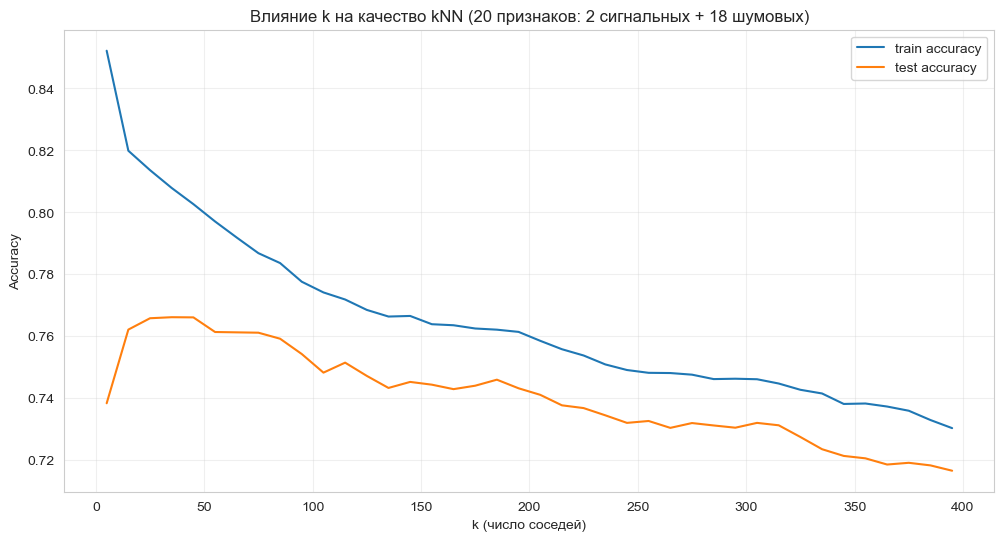

k=1: test accuracy = 0.7384
k=10: test accuracy = 0.7622
Оптимальный k = 35: test accuracy = 0.7662
Прирост accuracy: 0.0278


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

np.random.seed(42)

n_samples = 3000

# --- Сигнальные признаки (только 2) ---
# Класс 0: стабильная —— температура ~ 20°C, влажность ~ 40%
# Класс 1: нестабильная —— температура ~ 25°C, влажность ~ 60%

# Добавляем шум, чтобы классы перекрывались
temp0 = np.random.normal(20, 3.0, n_samples // 2)
hum0 = np.random.normal(40, 8.0, n_samples // 2)

temp1 = np.random.normal(25, 3.0, n_samples // 2)
hum1 = np.random.normal(60, 8.0, n_samples // 2)

temp = np.concatenate([temp0, temp1])
hum = np.concatenate([hum0, hum1])
y = np.concatenate([np.zeros(n_samples // 2), np.ones(n_samples // 2)])

# --- Шумовые признаки: 18 штук, все непрерывные, не связаны с таргетом ---
feature_names = [
    'temperature_storage', 'humidity_storage',
    'ph_value', 'moisture_content', 'dissolution_rate', 'hardness',
    'friability', 'particle_size', 'polymorph_ratio', 'assay_content',
    'impurity_a', 'impurity_b', 'impurity_c', 'residual_solvent',
    'color_intensity', 'turbidity', 'viscosity', 'melting_point',
    'sealing_strength', 'storage_time'
]

# Средние и стандартные отклонения для шумовых признаков (физически правдоподобные)
noise_params = {
    'ph_value': (7.0, 0.5),
    'moisture_content': (2.5, 0.8),
    'dissolution_rate': (750, 120),
    'hardness': (150, 30),
    'friability': (0.8, 0.3),
    'particle_size': (250, 50),
    'polymorph_ratio': (0.7, 0.15),
    'assay_content': (99.5, 1.2),
    'impurity_a': (50, 15),
    'impurity_b': (30, 10),
    'impurity_c': (20, 7),
    'residual_solvent': (100, 35),
    'color_intensity': (0.3, 0.1),
    'turbidity': (2.0, 0.8),
    'viscosity': (1.2, 0.4),
    'melting_point': (245, 5),
    'sealing_strength': (35, 8),
    'storage_time': (12, 4)
}

data = {'temperature_storage': temp, 'humidity_storage': hum}

for name, (mean, std) in noise_params.items():
    data[name] = np.random.normal(mean, std, n_samples)

df = pd.DataFrame(data)
df['target'] = y
df['class_name'] = df['target'].map({0: 'стабильная', 1: 'нестабильная'})

# --- Визуализация сигнальных признаков ---
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='temperature_storage', y='humidity_storage',
                hue='class_name', alpha=0.7)
plt.title('Стабильные vs Нестабильные партии (по сигнальным признакам)')
plt.xlabel('Температура хранения, °C')
plt.ylabel('Влажность при хранении, %')
plt.grid(True, alpha=0.3)
plt.show()

# --- Разделение на признаки и таргет ---
X = df.drop(columns=['target', 'class_name'])
y = df['target']

# --- kNN с разным количеством соседей ---
k_values = range(5, 400, 10)
train_scores = []
test_scores = []



for k in k_values:
    
    print(k)
    train_acc = []
    test_acc = []
    for seed in range(20):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)
        model = KNeighborsClassifier(k)
        model.fit(X_train, y_train)
        train_acc.append(accuracy_score(y_train, model.predict(X_train)))
        test_acc.append(accuracy_score(y_test, model.predict(X_test)))
    train_scores.append(np.mean(train_acc))
    test_scores.append(np.mean(test_acc))

plt.figure(figsize=(12, 6))
plt.plot(k_values, train_scores, label='train accuracy')
plt.plot(k_values, test_scores, label='test accuracy')
plt.xlabel('k (число соседей)')
plt.ylabel('Accuracy')
plt.title('Влияние k на качество kNN (20 признаков: 2 сигнальных + 18 шумовых)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Результаты
max_test_idx = np.argmax(test_scores)
print(f'k=1: test accuracy = {test_scores[0]:.4f}')
print(f'k=10: test accuracy = {test_scores[1]:.4f}')
print(f'Оптимальный k = {k_values[max_test_idx]}: test accuracy = {test_scores[max_test_idx]:.4f}')
print(f'Прирост accuracy: {(test_scores[max_test_idx] - test_scores[0]):.4f}')


5
20
35
50
65
80
95
110
125
140
155
170
185


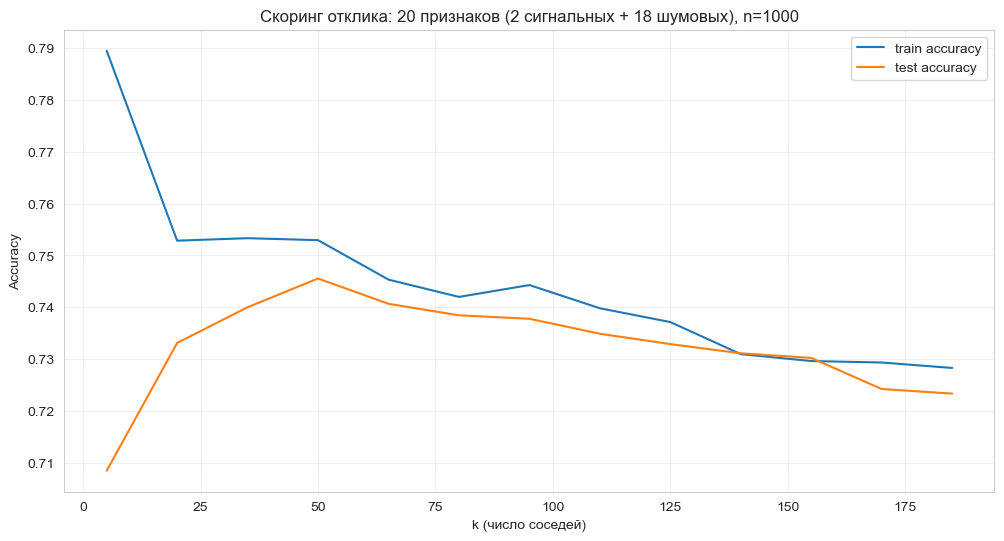

k=5: test accuracy = 0.7084
k=50: test accuracy = 0.7311
Оптимальный k = 50: test accuracy = 0.7456
Прирост accuracy: 0.0371


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

np.random.seed(42)

n_samples = 500  # маленькая выборка — эффект будет сильнее!

# --- Сигнальные признаки ---
# Клиенты, принявшие предложение: доход выше, скоринг выше
income0 = np.random.normal(50, 15, n_samples // 2)   # отказавшиеся
score0 = np.random.normal(600, 50, n_samples // 2)

income1 = np.random.normal(65, 15, n_samples // 2)   # принявшие
score1 = np.random.normal(650, 50, n_samples // 2)

income = np.concatenate([income0, income1])
score = np.concatenate([score0, score1])
y = np.concatenate([np.zeros(n_samples // 2), np.ones(n_samples // 2)])

# --- Генерируем шумовые признаки ---
noise_params = {
    'age': (45, 12),
    'tenure_months': (60, 40),
    'balance': (30, 25),
    'credit_limit': (50, 35),
    'num_products': (2.5, 1.2),
    'num_transactions': (20, 12),
    'avg_transaction_amount': (3, 2.5),
    'num_inquiries': (2, 1.8),
    'debt_ratio': (35, 15),
    'num_dependents': (1.2, 1.0),
    'years_employed': (8, 6),
    'education_level': (3, 1.2),
    'marital_status_code': (2.5, 1.0),
    'num_loans': (2, 1.4),
    'total_debt': (40, 30),
    'num_late_payments': (0.5, 1.0),
    'vehicle_age': (4, 3),
    'credit_mix': (2.0, 0.8)   # просто ещё один непрерывный
}

# Собираем DataFrame
data = {'annual_income': income, 'credit_score': score}

for name, (mean, std) in noise_params.items():
    data[name] = np.random.normal(mean, std, n_samples)

df = pd.DataFrame(data)
df['target'] = y
df['response'] = df['target'].map({0: 'отказ', 1: 'принятие'})

# --- Проверяем эффект ---
X = df.drop(columns=['target', 'response'])
y = df['target']

k_values = range(5, 200, 15)
test_scores = []
train_scores = []

for k in k_values:
    print(k)
    train_acc = []
    test_acc = []
    for seed in range(30):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)
        model = KNeighborsClassifier(k)
        model.fit(X_train, y_train)
        train_acc.append(accuracy_score(y_train, model.predict(X_train)))
        test_acc.append(accuracy_score(y_test, model.predict(X_test)))
    train_scores.append(np.mean(train_acc))
    test_scores.append(np.mean(test_acc))

plt.figure(figsize=(12, 6))
plt.plot(k_values, train_scores, label='train accuracy')
plt.plot(k_values, test_scores, label='test accuracy')
plt.xlabel('k (число соседей)')
plt.ylabel('Accuracy')
plt.title('Скоринг отклика: 20 признаков (2 сигнальных + 18 шумовых), n=1000')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

max_idx = np.argmax(test_scores)
print(f"k=5: test accuracy = {test_scores[0]:.4f}")
print(f"k=50: test accuracy = {test_scores[(50-1)//5]:.4f}")
print(f"Оптимальный k = {k_values[max_idx]}: test accuracy = {test_scores[max_idx]:.4f}")
print(f"Прирост accuracy: {test_scores[max_idx] - test_scores[0]:.4f}")


5
15
25
35
45
55
65
75
85
95
105
115
125
135
145
155
165
175
185
195


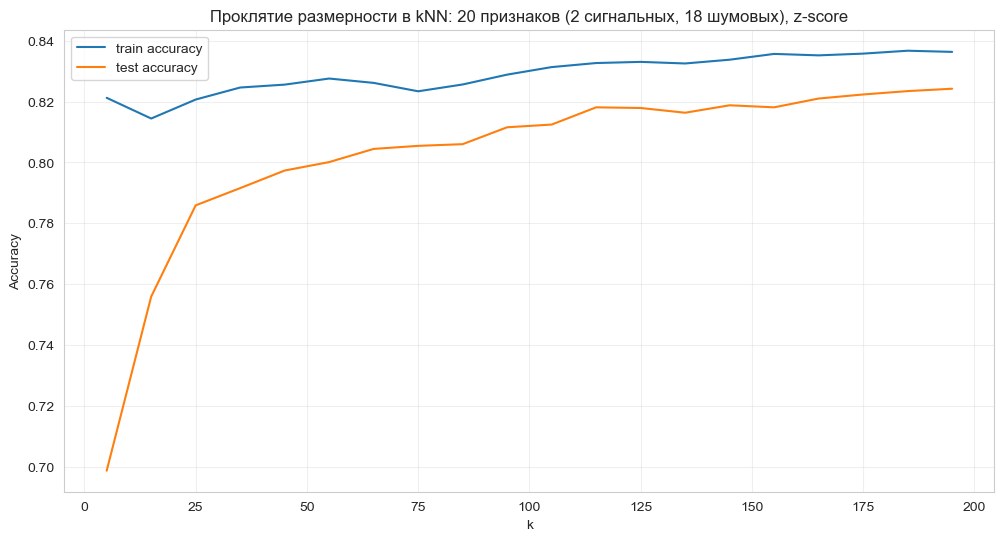

k=5: test accuracy = 0.6987
k=50: test accuracy = 0.8116
Оптимальный k = 195: test accuracy = 0.8242
Прирост accuracy: 0.1256


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

n_samples = 1000

# --- Сигнальные признаки: слабые, но перекрывающиеся ---
# Класс 0: mean = 0.40, std = 0.15
# Класс 1: mean = 0.60, std = 0.15
# Разница между классами = 0.20, стандартное отклонение = 0.15
# Это overlap = 1.33 (сильное перекрытие)

sig1_0 = np.random.normal(0.40, 0.15, n_samples // 2)
sig2_0 = np.random.normal(0.40, 0.15, n_samples // 2)

sig1_1 = np.random.normal(0.60, 0.15, n_samples // 2)
sig2_1 = np.random.normal(0.60, 0.15, n_samples // 2)

sig1 = np.concatenate([sig1_0, sig1_1])
sig2 = np.concatenate([sig2_0, sig2_1])

y = np.concatenate([np.zeros(n_samples // 2), np.ones(n_samples // 2)])

# --- Шумовые признаки: 18 штук, разброс больше сигнальных ---
# mean = 0.5, std = 0.4 (разброс в 2.7 раза больше, чем разница между классами)
# То есть вклад шумового признака в расстояние на порядок больше, чем сигнального

noise_features = []
for i in range(28):
    noise_features.append(np.random.normal(0.5, 0.4, n_samples))

# --- Собираем DataFrame ---
feature_names = [
    'vigor_index',          # сигнальный
    'stability_score',      # сигнальный
    'temperature', 'humidity', 'pressure', 'ph', 
    'viscosity', 'density', 'conductivity', 'elasticity',
    'hardness', 'porosity', 'turbidity', 'acidity',
    'conductance', 'resistance', 'permeability', 'solubility',
    'volatility', 'polarity', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10'
]

data = {'vigor_index': sig1, 'stability_score': sig2}
for i, name in enumerate(feature_names[2:]):
    data[name] = noise_features[i]

df = pd.DataFrame(data)
df['target'] = y

# --- Масштабируем ВСЕ признаки к стандартному виду (z-score) ---
# Это критично для честности, чтобы признаки были сопоставимы
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_names])
X = pd.DataFrame(X_scaled, columns=feature_names)

# --- Проверяем ---
k_values = range(5, 200, 10)
test_scores = []
train_scores = []

for k in k_values:
    print(k)
    train_acc = []
    test_acc = []
    for seed in range(30):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)
        model = KNeighborsClassifier(k)
        model.fit(X_train, y_train)
        train_acc.append(accuracy_score(y_train, model.predict(X_train)))
        test_acc.append(accuracy_score(y_test, model.predict(X_test)))
    train_scores.append(np.mean(train_acc))
    test_scores.append(np.mean(test_acc))

# Результаты
plt.figure(figsize=(12, 6))
plt.plot(k_values, train_scores, label='train accuracy')
plt.plot(k_values, test_scores, label='test accuracy')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Проклятие размерности в kNN: 20 признаков (2 сигнальных, 18 шумовых), z-score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

max_idx = np.argmax(test_scores)
print(f"k=5: test accuracy = {test_scores[0]:.4f}")
print(f"k=50: test accuracy = {test_scores[(50-1)//5]:.4f}")
print(f"Оптимальный k = {k_values[max_idx]}: test accuracy = {test_scores[max_idx]:.4f}")
print(f"Прирост accuracy: {test_scores[max_idx] - test_scores[0]:.4f}")
